In [20]:
import sys
from pathlib import Path

parent = Path.cwd().parent
sys.path.append(str(parent))

In [21]:
from src.integrator import ComplexIntegrator
from src.context_manager import ContextManager, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

import symbolica as sb

rng = sb.RandomNumberGenerator(1, 0)

In [22]:
cm = ContextManager(True)

Compiling evaluator: "combined_result"
Done!


In [23]:

eps = np.finfo(np.float64).eps

s = 350**2 # GeV
p12 = 120**2 # GeV
top_mass = 172.76 # GeV
bottom_mass = 4.18 # GeV
cm.masses = [top_mass, bottom_mass, top_mass]
cm.threshold = 500

In [24]:
cm.combined_integrand()

cm.origin = np.array([0,0,0,-37.9])

reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    cm.set_external_momenta(p12,p2**2,s)
    reference_values.append(cm.get_reference())

integral_values = []
p2s = np.linspace(200,210, 20)
for p2 in tqdm(p2s):
    cm.set_external_momenta(p12,p2**2,s)
    ci = ComplexIntegrator(3)
    res = ci.integrate(cm.eval, spherical, 50, 500, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:56<00:00,  2.82s/it]


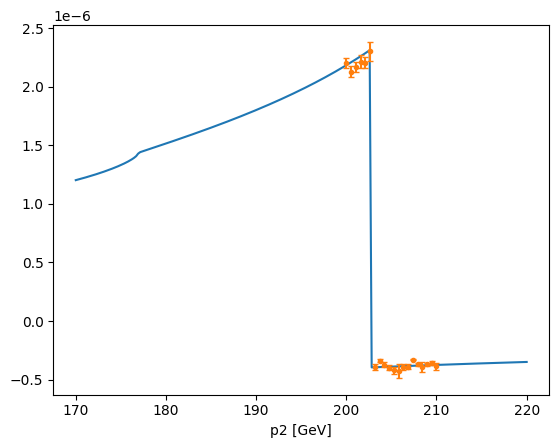

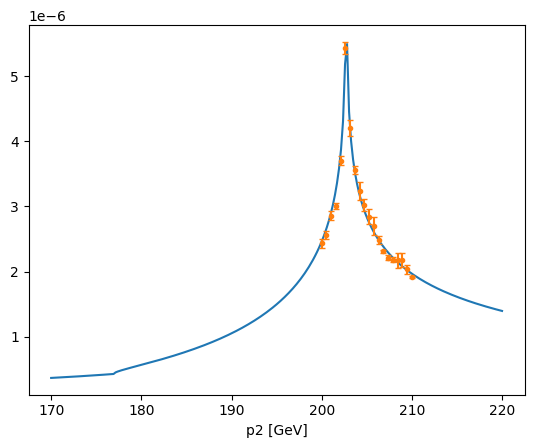

In [25]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

In [26]:

s = 350**2 # GeV
p12 = 120**2 # GeV
top_mass = 172.76-0.1j# GeV
bottom_mass = 4.18-0.1j# GeV
cm.masses = [top_mass, bottom_mass, top_mass]
cm.threshold = 500

In [29]:
cm.combined_integrand()

cm.origin = np.array([0,0,0,-37.9])

reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    cm.set_external_momenta(p12,p2**2,s)
    reference_values.append(cm.get_reference())

integral_values = []
p2s = np.linspace(200,210, 20)
for p2 in tqdm(p2s):
    cm.set_external_momenta(p12,p2**2,s)
    ci = ComplexIntegrator(3)
    res = ci.integrate(cm.eval, spherical, 50, 500, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:58<00:00,  2.91s/it]


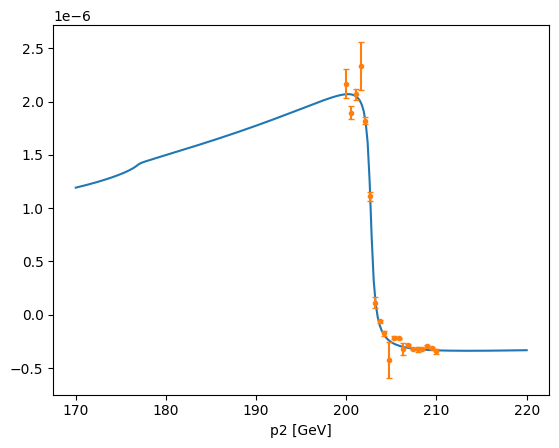

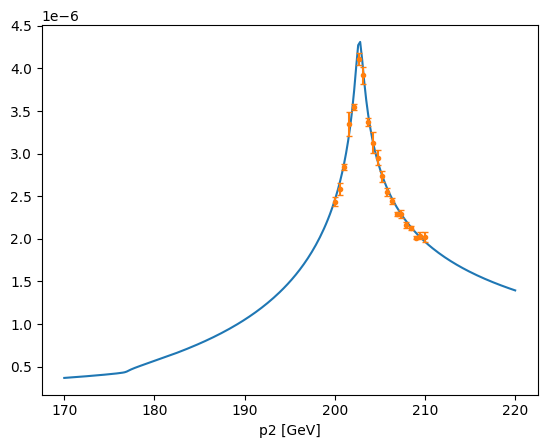

In [30]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()